**Can social media usage patterns predict variations in mental health outcomes (sleep quality, stress level, and happiness), and which indicators are the strongest predictors?**

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os, kagglehub

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os
import kagglehub
path = kagglehub.dataset_download("prince7489/mental-health-and-social-media-balance-dataset")
df = pd.read_csv(os.path.join(path, 'Mental_Health_and_Social_Media_Balance_Dataset.csv'))

In [5]:
#define initial variables
NUMERIC = ["Daily_Screen_Time(hrs)", "Days_Without_Social_Media"]
CAT = ["Social_Media_Platform"]
TARGET_NAMES = ["Sleep_Quality(1-10)", "Stress_Level(1-10)", "Happiness_Index(1-10)"]

#create a temporary copy to clean numeric features
df_temp = df.copy()

#force numeric conversion
for col in NUMERIC:
    df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

#check for NaNs across all relevant columns (features + targets)
all_data_columns = NUMERIC + TARGET_NAMES
bad_indices = df_temp[all_data_columns].isnull().any(axis=1)

#filter the main DataFrame to create a cleaned DataFrame
df_clean = df_temp[~bad_indices].copy()

#redefine X and Targets using the cleaned DataFrame ---
X = df_clean[NUMERIC + CAT]
TARGETS_clean = {name: df_clean[name] for name in TARGET_NAMES}

print(f"Original observations: {len(df)}")
print(f"Cleaned observations: {len(df_clean)}")

Original observations: 500
Cleaned observations: 500



Sleep_Quality(1-10) Pipeline -> MAE: 0.727, R2: 0.556


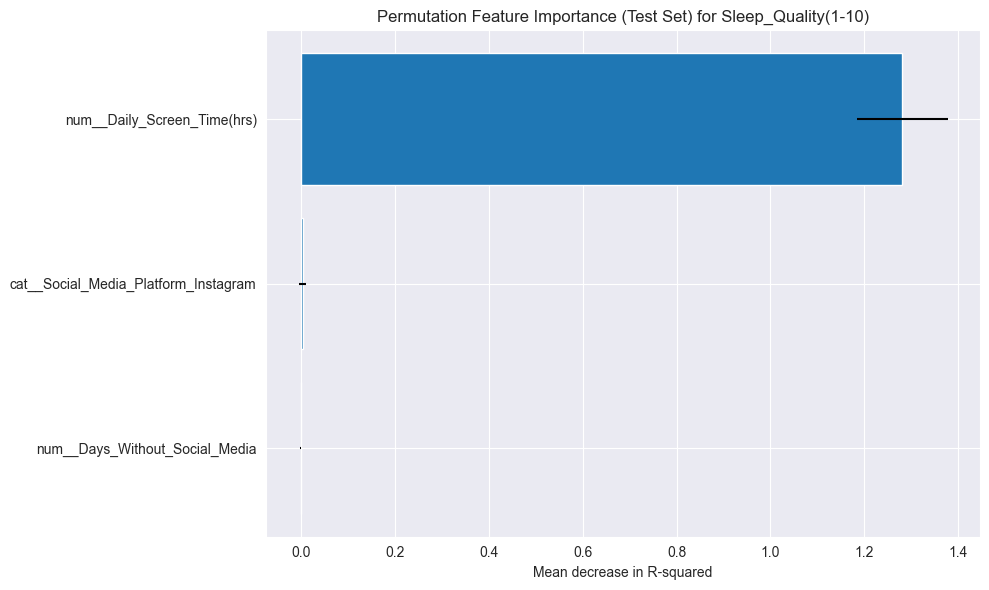


Stress_Level(1-10) Pipeline -> MAE: 0.865, R2: 0.545


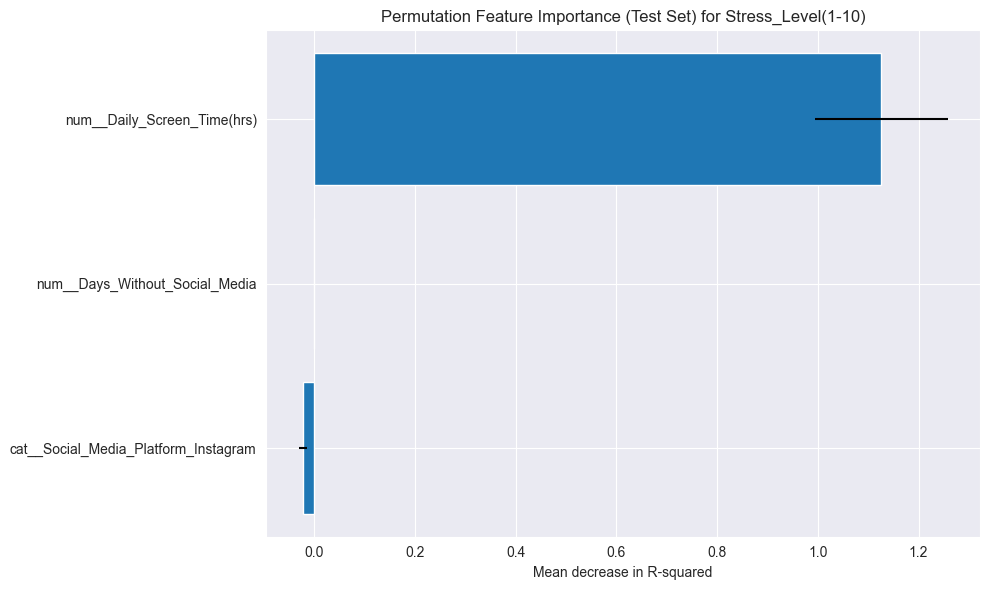


Happiness_Index(1-10) Pipeline -> MAE: 0.850, R2: 0.541


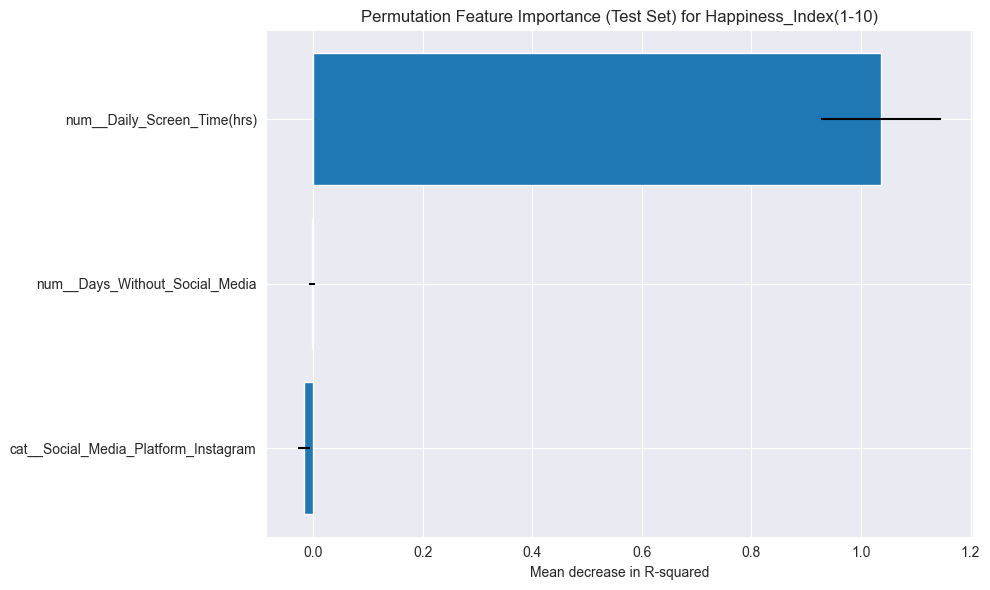

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

#pipeline setup
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT),],
    remainder='passthrough')

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())])

#fit, evaluate, and permutation importance for each target
for name, y in TARGETS_clean.items():
    #split data for the current target
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    
    #fit the model for the current target
    pipe.fit(X_tr, y_tr)
    
    #predict and metrics
    preds = pipe.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    print(f"\n{name} Pipeline -> MAE: {mae:.3f}, R2: {r2:.3f}")

    #permutation importance on test set
    r_perm = permutation_importance(pipe, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)
    
    #get feature names from the fitted pipeline preprocessor
    feature_names = list(pipe['prep'].get_feature_names_out(X.columns))
    
    #get the importance means and sort them for plotting
    sorted_idx = r_perm.importances_mean.argsort()
    
    #plot the result
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        [feature_names[i] for i in sorted_idx], 
        r_perm.importances_mean[sorted_idx],
        xerr=r_perm.importances_std[sorted_idx])
    
    ax.set_title(f"Permutation Feature Importance (Test Set) for {name}")
    ax.set_xlabel("Mean decrease in R-squared")
    fig.tight_layout()
    plt.show()

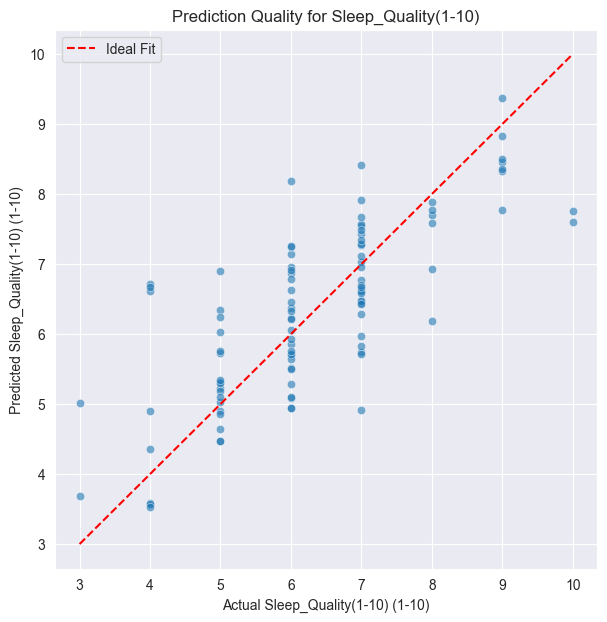

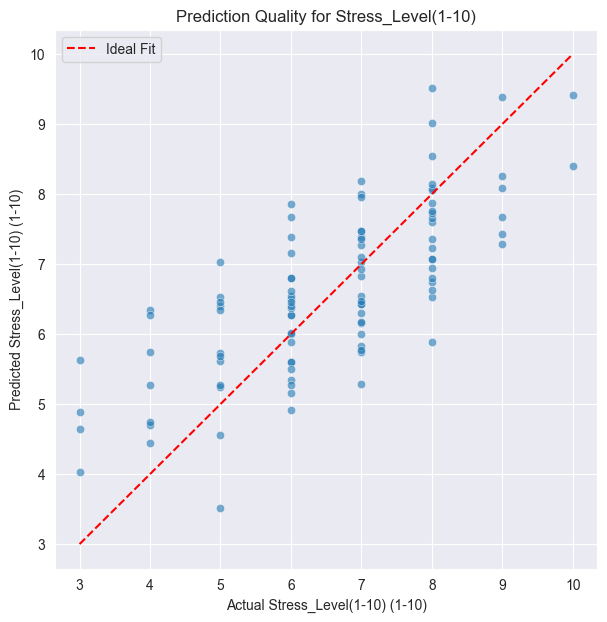

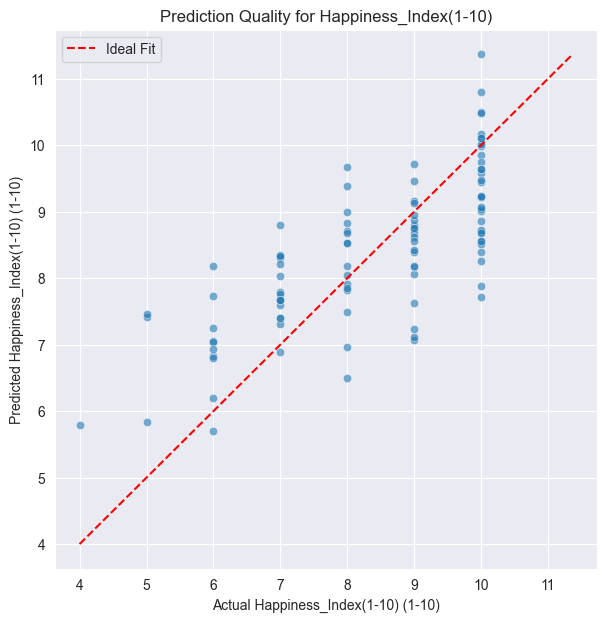

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, y in TARGETS_clean.items():
    #split data for the current target
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    
    #fit the pipeline model
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)

    #plot
    plt.figure(figsize=(7,7))
    sns.scatterplot(x=y_te, y=preds, alpha=0.6)
    
    plt.xlabel(f"Actual {name} (1-10)")
    plt.ylabel(f"Predicted {name} (1-10)")
    plt.title(f"Prediction Quality for {name}")
    
    max_val = max(y_te.max(), preds.max())
    min_val = min(y_te.min(), preds.min())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit') 
    
    plt.legend()
    plt.show()

In [8]:
import statsmodels.api as sm

#scale only numeric variables
X_numeric_scaled = (X[NUMERIC] - X[NUMERIC].mean()) / X[NUMERIC].std()

#encode categorical variables
X_cat_encoded = pd.get_dummies(X[CAT], drop_first=True)

#combine scaled numerics and unscaled categoricals
X_combined_float = pd.concat([X_numeric_scaled, X_cat_encoded], axis=1).astype(float)

#add the intercept
X_ols_const = sm.add_constant(X_combined_float, prepend=True)

#run OLS for each target
for target_name, y in TARGETS_clean.items():
    print(f"\n=== OLS Results for: {target_name} ===")
    
    #target needs to be a clean NumPy array
    y_array = y.astype(float).values
    
    #fit the OLS model
    model = sm.OLS(y_array, X_ols_const).fit()
    
    #print the summary
    print(model.summary())


=== OLS Results for: Sleep_Quality(1-10) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     96.65
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           2.85e-88
Time:                        20:21:44   Log-Likelihood:                -705.27
No. Observations:                 500   AIC:                             1427.
Df Residuals:                     492   BIC:                             1460.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

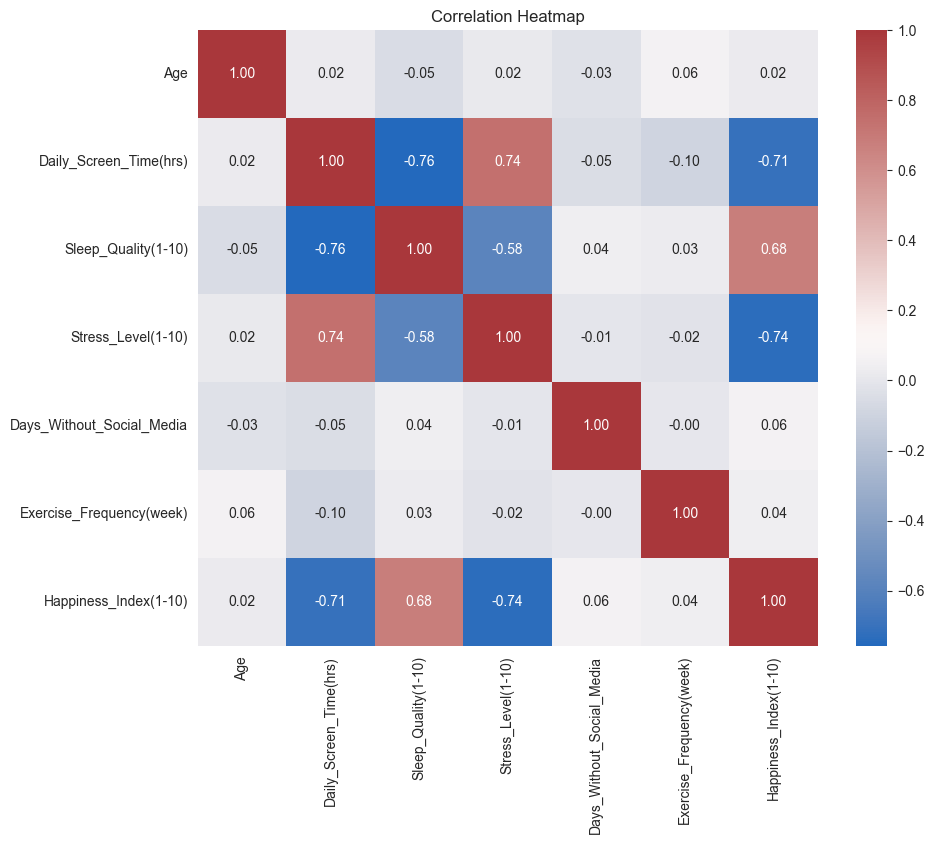

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_clean.corr(numeric_only=True), 
    annot=True, 
    cmap="vlag",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()